In [1]:
import polars as pl

in_conf = pl.read_parquet("../../data/in_v1/clustered/in_v1_proteins.conf.parquet")
in_rsa = pl.read_parquet("../../data/in_v1/clustered/in_v1_proteins.rsa.parquet")

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics


def plot_auc_from_df(
    df: pl.DataFrame,
    score_col: str,  # column with scores (often a List[float] per row)
    truth_col: str = "epitope_30mer_segment_boolmask",  # column with True/False labels (often List[bool])
    ax: plt.Axes | None = None,
    title: str | None = None,
) -> tuple[float, plt.Axes]:
    """
    Flattens `truth_col` and `score_col` using the implode/explode trick,
    computes ROC + AUC, and plots the ROC curve.

    Returns (auc, ax).
    """

    # Flatten columns using the provided technique
    # y_true: list[bool] or 0/1
    y_true = (
        df.select(pl.implode(truth_col).list.eval(pl.element().explode()))
        .to_series()
        .to_list()[0]
    )
    # y_score: list[float]
    y_score = (
        df.select(pl.implode(score_col).list.eval(pl.element().explode()))
        .to_series()
        .to_list()[0]
    )

    # Convert to numpy
    y_true = np.asarray(y_true, dtype=int)  # bool→{0,1} is fine
    y_score = np.asarray(y_score, dtype=float)

    # ROC and AUC
    fpr, tpr, _ = metrics.roc_curve(y_true, y_score)
    auc = metrics.roc_auc_score(y_true, y_score)

    # Plot
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.plot(fpr, tpr, lw=2, label=f"AUC {auc:.3f}")
    ax.plot([0, 1], [0, 1], "--", lw=1, color="grey")  # chance line
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    if title:
        ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(True)

    return auc, ax

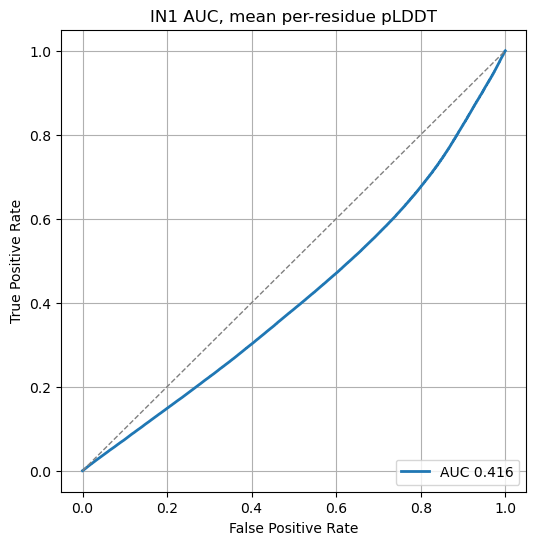

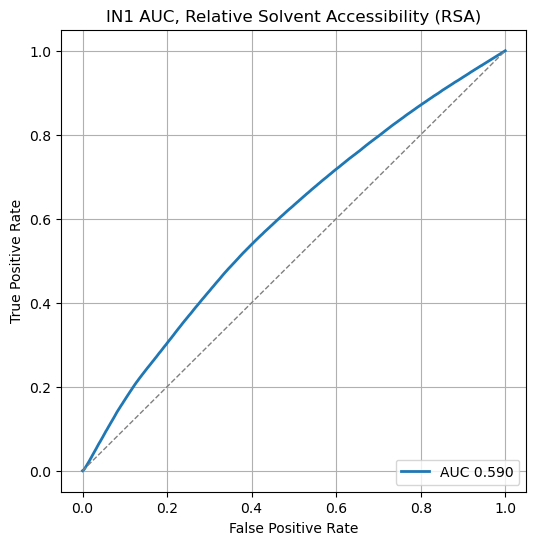

In [4]:
_ = plot_auc_from_df(
    in_conf,
    score_col="pLDDT",
    title="IN1 AUC, mean per-residue pLDDT"
)

_ = plot_auc_from_df(
    in_rsa,
    score_col="RSA",
    title="IN1 AUC, Relative Solvent Accessibility (RSA)"
)